# 프로젝트 3 - Weekend 2: LangGraph 기반 법률 에이전트 시스템

**프로젝트**: 법률 문서 기반 검색 에이전트 시스템 (Weekend 2/3)

**학습 목표**:
1. `StateGraph` + `TypedDict`로 법률 에이전트 상태 시스템 설계
2. 노드·엣지를 분리하여 `classify → search → analyze → answer` 그래프 구축
3. 조건부 라우팅과 ReAct 패턴으로 질문 유형별 최적 경로 구현
4. `MemorySaver`로 대화 이력 영속화 + Human-in-the-Loop


In [ ]:
# 환경 설정
!pip install -q langchain langchain-openai langchain-community faiss-cpu \
    langgraph pandas numpy python-dotenv

In [3]:
import os
import json
import time
from typing import TypedDict, Annotated, Literal
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
#from dotenv import load_dotenv
#load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


---
## 문제 1: Weekend 1 자산 복원

Weekend 2는 Weekend 1의 벡터스토어와 도구를 재사용합니다. 아래 셀에 **간소화된 복원 코드**를 작성하세요.

**요구사항:**
- `SAMPLE_LAW_ARTICLES` 리스트 (Weekend 1과 동일 데이터, 5개 이상 조문 포함)
- `law_docs`: `Document` 리스트 구축
- `vector_store`: FAISS 벡터스토어 구축
- `@tool` `search_law(query, top_k=3)`: 유사도 검색 도구
- 검증 함수 `verify_weekend1_assets()` 호출 → 체크포인트 출력

**평가기준:**
- `vector_store.similarity_search("이혼")` 결과 존재
- `search_law.name == "search_law"`

In [53]:
# 문제 1: Weekend 1 자산 복원 (간소화 버전)

# ---- 여기에 코드 작성 ----
# 1) SAMPLE_LAW_ARTICLES 정의 (아래 샘플 사용 가능)
SAMPLE_LAW_ARTICLES = [
    {"law": "민법", "article": "제750조", "title": "불법행위의 내용",
     "content": "고의 또는 과실로 인한 위법행위로 타인에게 손해를 가한 자는 그 손해를 배상할 책임이 있다."},
    {"law": "민법", "article": "제840조", "title": "재판상 이혼원인",
     "content": "부부의 일방은 1.부정한 행위 2.악의의 유기 3.부당한 대우 등의 사유가 있는 경우 이혼을 청구할 수 있다."},
    {"law": "형법", "article": "제307조", "title": "명예훼손",
     "content": "공연히 사실을 적시하여 사람의 명예를 훼손한 자는 2년 이하의 징역이나 500만원 이하의 벌금에 처한다."},
    {"law": "형법", "article": "제329조", "title": "절도",
     "content": "타인의 재물을 절취한 자는 6년 이하의 징역 또는 1천만원 이하의 벌금에 처한다."},
    {"law": "형법", "article": "제347조", "title": "사기",
     "content": "사람을 기망하여 재물의 교부를 받거나 재산상의 이익을 취득한 자는 10년 이하의 징역 또는 2천만원 이하의 벌금에 처한다."},
    {"law": "상법", "article": "제382조", "title": "이사의 선임, 임기",
     "content": "이사는 주주총회에서 선임하며, 임기는 3년을 초과하지 못한다."},
]

# 2) law_docs 구축
law_docs = [Document(
    page_content = article['content'], metadata = {'law' : article['law'], 'article' : article['article'], 'title' : article['title']}
    ) for article in SAMPLE_LAW_ARTICLES
] # Document 리스트로 변환

# 3) vector_store 구축
vector_store = FAISS.from_documents(
    documents = law_docs,
    embedding = embeddings
    )  # FAISS.from_documents() 사용

# 4) @tool search_law 정의
@tool
def search_law(query: str, top_k: int = 3) -> str:
    """법률 조문을 의미 기반으로 검색합니다.
    질문과 관련된 법률 조문을 찾아 반환합니다.

    Args:
        query: 검색 질의 (예: "이혼 사유", "명예훼손 처벌")
        top_k: 반환할 조문 수 (기본 3)
    """
    raw_results = vector_store.similarity_search(query, k=top_k)

    results = []

    for item in raw_results:
      results.append({
          "law": item.metadata.get('law'),
          "article": item.metadata.get('article'),
          "title": item.metadata.get('title'),
          "content" : item.page_content
      })

    return json.dumps(results, ensure_ascii=False, indent=2)


def verify_weekend1_assets():
    """Weekend 1 자산 복원 검증."""
    checks = {
        "SAMPLE_LAW_ARTICLES": len(SAMPLE_LAW_ARTICLES) >= 5,
        "law_docs": law_docs is not None and len(law_docs) >= 5,
        "vector_store": vector_store is not None,
        #"search_law tool": 'search_law' in dir() and hasattr(search_law, 'name'),
        "search_law tool": 'search_law' in globals() and hasattr(search_law, 'name'),
    }
    for name, ok in checks.items():
        print(f"  {'✅' if ok else '❌'} {name}")
    return all(checks.values())

verify_weekend1_assets()

  ✅ SAMPLE_LAW_ARTICLES
  ✅ law_docs
  ✅ vector_store
  ✅ search_law tool


True

In [29]:
# 함수 테스트
def search_law(query: str, top_k: int = 3) -> str:
    raw_results = vector_store.similarity_search(query, k=top_k)
    results = []
    for item in raw_results:
      results.append({
          "law": item.metadata.get('law'),
          "article": item.metadata.get('article'),
          "title": item.metadata.get('title'),
          "content" : item.page_content
      })
    return json.dumps(results, ensure_ascii=False, indent=2)

query = "손해배상 관련 조문"
print(search_law(query))

[
  {
    "law": "민법",
    "article": "제750조",
    "title": "불법행위의 내용",
    "content": "고의 또는 과실로 인한 위법행위로 타인에게 손해를 가한 자는 그 손해를 배상할 책임이 있다."
  },
  {
    "law": "상법",
    "article": "제382조",
    "title": "이사의 선임, 임기",
    "content": "이사는 주주총회에서 선임하며, 임기는 3년을 초과하지 못한다."
  },
  {
    "law": "형법",
    "article": "제307조",
    "title": "명예훼손",
    "content": "공연히 사실을 적시하여 사람의 명예를 훼손한 자는 2년 이하의 징역이나 500만원 이하의 벌금에 처한다."
  }
]


---
## 문제 2: `LegalAgentState` 정의

LangGraph가 노드 간에 전달할 상태를 `TypedDict`로 정의하세요.

**요구사항:**
- `LegalAgentState`라는 TypedDict 클래스
- 필드:
  - `messages`: `Annotated[list[BaseMessage], add_messages]` (LangGraph가 자동 병합)
  - `query`: `str` (원본 질문)
  - `question_type`: `Literal["article_search", "case_search", "term_explain", "general"]`
  - `search_results`: `list[dict]` (검색된 조문)
  - `answer`: `str` (최종 답변)

**평가기준:**
- `LegalAgentState`가 `TypedDict`의 서브클래스
- 5개 필드가 모두 정의됨
- `Annotated[..., add_messages]`가 messages에 적용됨

In [52]:
# 문제 2: LegalAgentState
from typing import TypedDict, Annotated, Literal
# typing 모듈의 Annotated는 변수의 '타입'에 '추가적인 정보(꼬리표)'를 달아줄 때 사용
  # 형태: Annotated[기본타입, 추가정보]
  # 의미: 변수는 기본타입이지만, 다룰 때는 추가정보라는 규칙을 참고
  # 사용 이유: 일반적으로 파이썬 딕셔너리(TypedDict 포함)에서 값을 업데이트하면 기존 값이 덮어쓰기(Overwrite)됨
    # 하지만 대화 기록(messages)은 덮어쓰면 안되므로 기존 대화 리스트 뒤에 새로운 대화를 계속 추가하기 위함
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class LegalAgentState(TypedDict):
    # 정의된 필드들 == 그래프 전체가 공유하는 상태(State)
    messages : Annotated[list[BaseMessage], add_messages]
    query : str
    # 리터럴: 변수에 들어갈 수 있는 값(선택지)을 미리 정해두고, 그중에서만 고르도록 제한하는 역할
    question_type : Literal["article_search", "case_search", "term_explain", "general"]
    search_results : list[dict] # 검색된 조문
    answer : str

# 테스트: 샘플 상태 생성
sample_state = LegalAgentState(
    messages=[HumanMessage(content="이혼 사유는?")],
    query="이혼 사유는?",
    question_type="article_search",
    search_results=[],
    answer="",
)
print("✅ LegalAgentState 필드:", list(LegalAgentState.__annotations__.keys()))

✅ LegalAgentState 필드: ['messages', 'query', 'question_type', 'search_results', 'answer']


---
## 문제 3: `classify_node` — 질문 유형 분류 노드

질문을 4개 유형 중 하나로 분류하는 노드 함수를 구현하세요.

**요구사항:**
- 함수 시그니처: `classify_node(state: LegalAgentState) -> dict`
- LLM에게 질문 유형 분류 요청 (프롬프트에 4개 타입 후보 명시)
- 반환값: `{"question_type": "article_search" | "case_search" | "term_explain" | "general"}`
- LLM이 예상 밖 응답 반환 시 "general"로 fallback

**평가기준:**
- "이혼 사유는?" → "article_search"
- "이혼 관련 판례 알려줘" → "case_search"
- "미필적 고의가 뭐야?" → "term_explain"
- "안녕" → "general"

In [34]:
# 문제 3: classify_node
def classify_node(state):
    """질문 유형을 분류합니다."""
    query = state["query"]

    # ---- 여기에 코드 작성 ----
    # 1) LLM에게 분류 요청 프롬프트 작성
    messages =[
        SystemMessage(content="""
          당신은 법률 질문 분류 전문가입니다.
          사용자의 질문을 분석하여 다음 4가지 유형 중 정확히 하나만 답변하세요. 다른 부가적인 설명은 절대 하지 마세요.[분류 기준]
          1. article_search : 법령 조문, 사유, 요건 등 법적 근거에 대한 질문
          2. case_search : 판례, 재판 결과에 대한 질문 (예: "관련 판례 알려줘")
          3. term_explain : 법률 용어의 뜻이나 개념 설명 (예: "불법 행위가 뭐야?")
          4. general : 법률과 무관한 일상 대화나 인사 (예: "안녕", "고마워")
          """),
        HumanMessage(content=query)
    ]
    response = llm.invoke(messages)
    # 2) response.content.strip().lower() 등으로 결과 정규화
    question_type = response.content.strip().lower()
    # 3) 4개 유형 중 하나가 아니면 "general"로 fallback
    if question_type not in ['article_search', 'case_search', 'term_explain', 'general']:
      question_type = "general"

    return {"question_type": question_type}

# 테스트
test_queries = [
    "이혼 사유는 뭐가 있어?",
    "명예훼손 관련 판례 알려줘",
    "미필적 고의가 뭐야?",
    "안녕하세요",
]
for q in test_queries:
    state = LegalAgentState(messages=[], query=q, question_type="", search_results=[], answer="")
    result = classify_node(state)
    print(f"  '{q}' → {result['question_type']}")

  '이혼 사유는 뭐가 있어?' → article_search
  '명예훼손 관련 판례 알려줘' → case_search
  '미필적 고의가 뭐야?' → term_explain
  '안녕하세요' → general


---
## 문제 4: `search_node` + `analyze_node`

검색 노드와 분석 노드를 각각 구현하세요.

**요구사항:**

**`search_node(state)`**:
- `state["query"]`로 vector_store 검색 (k=3)
- 결과를 `search_results` 필드에 dict 리스트로 저장: `[{"law":..., "article":..., "title":..., "content":...}]`

**`analyze_node(state)`**:
- `state["search_results"]`를 LLM 프롬프트에 포함
- 질문에 답변 생성
- 반환: `{"messages": [AIMessage(content=answer)], "answer": answer}`

**평가기준:**
- `search_node` 반환값에 `search_results` 키 존재 (리스트 3개)
- `analyze_node` 반환값에 `messages`와 `answer` 키 존재

In [39]:
# 문제 4: search_node + analyze_node
def search_node(state):
    """벡터 검색으로 관련 조문을 찾습니다."""
    query = state["query"]
    search_results = []

    results = vector_store.similarity_search(query, k=3)

    for item in results:
      search_results.append({
          "law": item.metadata.get('law'),
          "article": item.metadata.get('article'),
          "title": item.metadata.get('title'),
          "content" : item.page_content
      })
    return {"search_results": search_results}

def analyze_node(state):
    """검색 결과를 바탕으로 답변을 생성합니다."""
    query = state["query"]
    results = state["search_results"]
    # 1) 검색 결과를 프롬프트에 포맷팅
    formatted_contexts =[]
    for i, item in enumerate(results, start=1):
        # 포맷 예시
        # [1] 민법 제840조(재판상 이혼원인)
        # 내용: 부부 일방은 다음 각호의 사유가 있는 경우에는 ...
        context_str = f"[{i}] {item['law']} 제{item['article']}조({item['title']})\n내용: {item['content']}"
        formatted_contexts.append(context_str)
        context_text = "\n\n".join(formatted_contexts)

    # 2) LLM에 답변 요청
    messages = [
        SystemMessage(content=f"""
          당신은 법률 전문 에이전트 입니다.
          아래 제공된 [법률 검색 결과]를 바탕으로 사용자의 질문에 답변하세요.
          [법률 검색 결과]:{context_text}
        """),
        HumanMessage(content = query)
    ]
    response = llm.invoke(messages)

    # 3) AIMessage와 answer 반환
    answer = response.content
    return {"messages": [AIMessage(content=answer)], "answer": answer}

# 테스트 (search만)
test_state = LegalAgentState(
    messages=[], query="이혼 사유", question_type="article_search",
    search_results=[], answer=""
)
search_out = search_node(test_state)
print(f"검색 결과 {len(search_out.get('search_results', []))}개")
for r in search_out.get('search_results', [])[:2]:
    print(f"  - {r.get('law')} {r.get('article')}")

검색 결과 3개
  - 민법 제840조
  - 민법 제750조


In [37]:
search_out

{'search_results': [{'law': '민법',
   'article': '제840조',
   'title': '재판상 이혼원인',
   'content': '부부의 일방은 1.부정한 행위 2.악의의 유기 3.부당한 대우 등의 사유가 있는 경우 이혼을 청구할 수 있다.'},
  {'law': '민법',
   'article': '제750조',
   'title': '불법행위의 내용',
   'content': '고의 또는 과실로 인한 위법행위로 타인에게 손해를 가한 자는 그 손해를 배상할 책임이 있다.'},
  {'law': '상법',
   'article': '제382조',
   'title': '이사의 선임, 임기',
   'content': '이사는 주주총회에서 선임하며, 임기는 3년을 초과하지 못한다.'}]}

In [42]:
# analyze node 확인용
# 상태(State) 업데이트
# LangGraph가 나중에 자동으로 해주는 과정이지만, 단독 테스트 시에는 수동으로 갱신 필요
test_state["search_results"] = search_out["search_results"]

# analyze_node 실행
analyze_out = analyze_node(test_state)

# 최종 답변 확인
print("\n" + "="*50)
print("[AI 답변 결과]")
print("="*50)
print(analyze_out["answer"])


[AI 답변 결과]
이혼 사유는 민법 제840조에 규정되어 있습니다. 이 조항에 따르면, 부부의 일방은 다음과 같은 사유가 있는 경우 이혼을 청구할 수 있습니다:

1. 부정한 행위 (즉, 배우자의 외도)
2. 악의의 유기 (즉, 배우자가 고의로 다른 배우자를 버리는 경우)
3. 부당한 대우 (즉, 배우자가 상대방에게 심각한 정신적 또는 신체적 고통을 주는 경우)

이러한 사유가 있을 경우, 이혼을 청구할 수 있는 법적 근거가 마련됩니다.


---
## 문제 5: StateGraph 기본 구축

`classify → search → analyze` 순서로 노드를 연결한 그래프를 만드세요.

**요구사항:**
- `StateGraph(LegalAgentState)`로 그래프 빌더 생성
- 3개 노드 등록 (`classify`, `search`, `analyze`)
- 엣지 연결: `START → classify → search → analyze → END`
- `.compile()`로 실행 가능한 그래프 반환
- 함수 시그니처: `build_basic_graph() -> CompiledStateGraph`

**평가기준:**
- `graph.invoke({...})` 호출 가능
- 최종 state에 `answer` 필드가 채워짐

In [43]:
# 문제 5: StateGraph 기본 구축
def build_basic_graph():
    """classify → search → analyze 순서 그래프."""
    builder = StateGraph(LegalAgentState)
    # 1) 노드 3개 추가 (add_node)
    builder.add_node('classify', classify_node)
    builder.add_node('search', search_node)
    builder.add_node('analyze', analyze_node)

    # 2) 엣지 4개 연결 (START → classify → search → analyze → END)
    builder.add_edge(START, 'classify')
    builder.add_edge('classify', 'search')
    builder.add_edge('search', 'analyze')
    builder.add_edge('analyze', END)

    # 3) builder.compile() 반환
    return builder.compile()

# 테스트
graph = build_basic_graph()
if graph:
    initial = {
        "messages": [HumanMessage(content="명예훼손 처벌은?")],
        "query": "명예훼손 처벌은?",
        "question_type": "",
        "search_results": [],
        "answer": "",
    }
    result = graph.invoke(initial)
    print(f"🤖 질문 유형: {result['question_type']}")
    print(f"📚 검색 결과: {len(result['search_results'])}개")
    print(f"💬 답변: {result['answer'][:200]}")

🤖 질문 유형: article_search
📚 검색 결과: 3개
💬 답변: 명예훼손에 대한 처벌은 형법 제307조에 규정되어 있습니다. 공연히 사실을 적시하여 사람의 명예를 훼손한 경우, 2년 이하의 징역형 또는 500만원 이하의 벌금에 처해질 수 있습니다.


---
## 문제 6: 조건부 라우팅 — 질문 유형별 분기

질문 유형에 따라 다른 노드로 분기하도록 그래프를 확장하세요.

**요구사항:**
- `term_node(state)`: 용어 설명 전용 노드 (간단한 LLM 호출)
- `general_node(state)`: 일반 질문 대답 노드
- 라우터 함수 `route_by_type(state)`: state["question_type"]에 따라 다음 노드명 반환
  - `article_search` / `case_search` → `"search"`
  - `term_explain` → `"term"`
  - `general` → `"general"`
- `add_conditional_edges(classify, route_by_type, {...})` 로 분기
- 함수 시그니처: `build_routed_graph() -> CompiledStateGraph`

**평가기준:**
- "이혼" → search 경로
- "미필적 고의" → term 경로
- "안녕" → general 경로

### 📖 분기 흐름 설명
- 1단계: classify 노드가 question_type을 결정
  - classify 노드가 사용자의 질문을 LLM에 보내고, 응답을 state["question_type"]에 저장
  ```
  "이혼"       → classify → state["question_type"] = "article_search"
  "미필적 고의" → classify → state["question_type"] = "term_explain"
  "안녕"       → classify → state["question_type"] = "general"
  ```
- 2단계: route_by_type이 다음 노드명을 반환
  - 해당 노드는 LLM을 호출하지 않고, 단순히 state["question_type"]에 이미 저장된 값을 읽은 후, 조건문으로 노드 이름 문자열을 반환

- 3단계: add_conditional_edges가 매핑
    ```
    # 3) classify 이후 조건부 분기
        builder.add_conditional_edges(
            "classify",        # 이 노드가 끝나면
            route_by_type,     # 이 함수 호출 → 반환값이 아래 딕셔너리의 key
            {
                "search":  "search",
                "term":    "term",
                "general": "general",
            }
        )
    ```

In [45]:
# 문제 6: 조건부 라우팅 그래프
def term_node(state):
    """용어 설명 전용 노드."""
    query = state["query"]
    messages = [
        SystemMessage(content="""
        당신은 법률 용어 전문가입니다.
        사용자가 질문한 법률 용어를 정확하고 쉽게 설명해 주세요.
        """),
        HumanMessage(content=query)
    ]
    response = llm.invoke(messages)
    answer = response.content
    return {"messages": [AIMessage(content=answer)], "answer": answer}

def general_node(state):
    """일반 질문 노드."""
    query = state["query"]
    messages = [
        SystemMessage(content="""
        당신은 친절한 AI 어시스턴트입니다.
        사용자의 일반적인 질문에 자연스럽게 대답해 주세요.
        """),
        HumanMessage(content=query)
    ]
    response = llm.invoke(messages)
    answer = response.content
    return {"messages": [AIMessage(content=answer)], "answer": answer}

def route_by_type(state):
    """질문 유형으로 다음 노드를 결정."""
    #question_type : Literal["article_search", "case_search", "term_explain", "general"]

    # X 잘못된 사용법: state에서 값을 꺼내려 함 → KeyError
      # return state['search_node']
      # 라우터 함수는 노드 이름 문자열 자체를 반환해야 함
    if state["question_type"] == "article_search":
      return "search"
    elif state["question_type"] == "case_search":
      return "search"
    elif state["question_type"] == "term_explain":
      return "term"

    return "general"



def build_routed_graph():
    builder = StateGraph(LegalAgentState)
    # 1) 노드 추가: classify, search, analyze, term, general
    builder.add_node("classify", classify)
    builder.add_node("search", search_node)
    builder.add_node("analyze", analyze_node)
    builder.add_node("term", term_node)
    builder.add_node("general", general_node)

    # 2) START → classify
    builder.add_edge(START, "classify")

    # 3) classify에서 add_conditional_edges(route_by_type, {...})
    builder.add_conditional_edges(
        "classify",
        route_by_type,
        {
            "search":  "search",
            "term":    "term",
            "general": "general",
        }
    )

    # 4) search → analyze → END
    builder.add_edge("search", "analyze")
    builder.add_edge("analyze", END)

    # 5) term → END, general → END
    builder.add_edge("term", END)
    builder.add_edge("general", END)

    return builder.compile()

# 테스트
graph = build_routed_graph()
if graph:
    for q in ["이혼 사유는?", "미필적 고의가 뭐야?", "안녕하세요"]:
        initial = {
            "messages": [HumanMessage(content=q)], "query": q,
            "question_type": "", "search_results": [], "answer": "",
        }
        result = graph.invoke(initial)
        print(f"  '{q}' [{result['question_type']}] → {result['answer'][:80]}...")

  '이혼 사유는?' [article_search] → 이혼 사유는 민법 제840조에 명시되어 있습니다. 이 조항에 따르면, 부부의 일방은 다음과 같은 사유가 있는 경우 이혼을 청구할 수 있습니다:
...
  '미필적 고의가 뭐야?' [term_explain] → 미필적 고의(未必的故意)는 형법에서 사용되는 용어로, 범죄자가 자신의 행위로 인해 결과가 발생할 가능성을 인식하면서도 그 결과가 발생하길 바라는...
  '안녕하세요' [general] → 안녕하세요! 어떻게 도와드릴까요?...


---
## 문제 7: ReAct 패턴 — 도구 호출 루프

LLM이 필요에 따라 `search_law` 도구를 반복 호출하는 ReAct 패턴 그래프를 구현하세요.

**요구사항:**
- `agent_node(state)`: `llm_with_tools.invoke(messages)` 호출 후 메시지 반환
- `tool_node(state)`: 마지막 AIMessage의 tool_calls를 실행하여 ToolMessage 반환
- `should_continue(state)`: 마지막 메시지에 tool_calls 있으면 `"tools"`, 없으면 `END`
- 그래프: `START → agent ⇄ tools`, agent의 조건부 엣지로 종료 결정
- 함수 시그니처: `build_react_graph(tools: list) -> CompiledStateGraph`

**평가기준:**
- 도구 호출이 필요한 질문 시 tool_node 실행 기록
- 최종 응답에 AIMessage 포함

#### tool_calls가 뭔지?
agent_node에서 LLM을 호출하면 AIMessage가 반환되며, AIMessage 안에 tool_calls라는 리스트가 자동으로 들어있음.
```
response = llm_with_tools.invoke([HumanMessage(content="사기죄 형량 알려줘")])
print(response.tool_calls)
```
```
# 출력 결과:
[
    {
        "name": "search_law",           # 어떤 도구를 호출할지
        "args": {"query": "사기죄 형량"},  # 어떤 인자로 호출할지
        "id": "call_abc123"              # 이 호출의 고유 ID
    }
]
```

In [54]:
tools = [search_law]
llm_with_tools = llm.bind_tools(tools)
# t.name은 직접 저장한 적은 없지만
## @tool을 붙이는 순간 LangChain이 함수 이름을 가져와서 .name 속성에 저장함
tool_map = {t.name: t for t in tools}

In [55]:
# 문제 7: ReAct 패턴

def agent_node(state):
    """LLM이 응답 또는 도구 호출을 결정."""
    response = llm_with_tools.invoke(state["messages"])
    # LLM이 메시지를 보고 도구가 필요하다고 판단되면(llm_with_tools) → tool_calls가 포함된 AIMessage 반환
    # 아니라면 일반 텍스트 AIMessage 반환
    # 여기서 LLM이 직접 도구를 실행하는 건 아님
    return {"messages": [response]}

def tool_node(state):
    """마지막 AIMessage의 tool_calls 실행."""
    # last_msg는 사용자 입력이 아님. agent_node가 방금 추가한 LLM의 AIMessage
    last_msg = state["messages"][-1]

    # tool_calls 순회 → tool_map으로 실행 → ToolMessage 생성
    results = []
    for call in last_msg.tool_calls:
        # call = {"name": "search_law", "args": {"query": "사기죄"}, "id": "call_1"}
        output = tool_map[call["name"]].invoke(call["args"])  # 이름으로 함수 찾아서 실행
        results.append(
            ToolMessage(content=str(output), tool_call_id=call["id"])  # 결과를 id와 매칭
        )

    return {"messages": results}

def should_continue(state):
    """도구 호출 여부로 계속 실행 or 종료."""
    # 동작 흐름
    # 1. agent_node에서 llm_with_tools.invoke() 호출
    # 2. LLM이 "도구가 필요하다"고 판단하면 → AIMessage에 tool_calls 리스트를 채워서 반환
    # 3. AIMessage가 messages의 마지막([-1])에 추가됨
    # 4. should_continue가 마지막 메시지의 tool_calls를 확인 → 있으면 "tools", 없으면 END
    return "tools" if state['messages'][-1].tool_calls else END

def build_react_graph(tools):
    tool_map = {t.name: t for t in tools}
    llm_with_tools = llm.bind_tools(tools)

    # 전역으로 저장 (노드 함수에서 접근)
    global _react_tool_map, _react_llm_with_tools
    _react_tool_map = tool_map
    _react_llm_with_tools = llm_with_tools

    builder = StateGraph(LegalAgentState)
    # 1) agent 노드, tools 노드 추가
    builder.add_node("agent", agent_node)
    builder.add_node("tools", tool_node)

    # 2) START → agent
    builder.add_edge(START, "agent")

    # 3) agent에서 should_continue로 조건부 엣지: "tools" → tools, END → END
    builder.add_conditional_edges(
        "agent",
        should_continue, # 함수를 호출해서
        {"tools": "tools", END: END} # 반환값이 "tools"면 → "tools" 노드로, END면 → 종료
    )
    # 4) tools → agent
    builder.add_edge("tools", "agent")

    return builder.compile()

# 테스트 (search_law만 준비되어 있다면)
if 'search_law' in dir():
    graph = build_react_graph([search_law])
    if graph:
        initial = {
            "messages": [HumanMessage(content="사기죄 형량을 알려줘")],
            "query": "사기죄 형량을 알려줘",
            "question_type": "", "search_results": [], "answer": "",
        }
        result = graph.invoke(initial)
        print(f"최종 메시지 수: {len(result['messages'])}")
        print(f"마지막 답변: {result['messages'][-1].content[:200]}")

최종 메시지 수: 4
마지막 답변: 사기죄에 대한 형량은 다음과 같은 법률 조문에서 확인할 수 있습니다:

1. **형법 제329조 (절도)**: 타인의 재물을 절취한 자는 6년 이하의 징역 또는 1천만원 이하의 벌금에 처한다. (사기죄와 관련된 조문은 아니지만, 유사한 범죄에 대한 형량을 참고할 수 있습니다.)

현재 제공된 정보에는 사기죄에 대한 구체적인 형량이 포함되어 있지 않습니다. 


---
## 문제 8: `MemorySaver` — 대화 이력 영속화

`MemorySaver`를 체크포인터로 사용하여 `thread_id` 별로 대화 이력을 유지하세요.

**요구사항:**
- `build_memory_graph(tools)`: ReAct 그래프에 `checkpointer=MemorySaver()` 적용
- 테스트: 같은 `thread_id`로 2번 호출 시 이전 대화 참고 가능
- `config={"configurable": {"thread_id": "user1"}}` 형식으로 실행
- `graph.get_state(config)`로 현재 상태 조회 가능 확인

**평가기준:**
- 첫 질문 후 두 번째 질문에서 맥락 유지
- `graph.get_state(config).values["messages"]` 길이가 누적됨

#### 📖 MemorySaver
- 일반 그래프(compile())는 실행이 끝나면 상태가 사라지지만, MemorySaver를 붙이면 thread_id별로 상태를 자동 저장함
  ```
  thread_id = "alice"  → alice 채팅방 (대화 이력 자동 누적)
  thread_id = "bob"    → bob 채팅방 (완전 별개의 이력)
  ```
- 차이점
  1. 컴파일할 때 checkpointer=MemorySaver() 추가
    ```
    graph = builder.compile(checkpointer=MemorySaver())
    ```
  2. 호출할 때 config=cfg로 thread_id 전달
    ```
    cfg = {"configurable": {"thread_id": "alice"}}
    graph.invoke({"messages": [HumanMessage("내 이름은 앨리스야")]}, config=cfg)
    graph.invoke({"messages": [HumanMessage("내 이름이 뭐야?")]}, config=cfg)
    ```

In [56]:
# 문제 8: MemorySaver 통합
def build_memory_graph(tools):
    """MemorySaver를 체크포인터로 사용하는 그래프."""
    # 1) build_react_graph와 유사하게 빌더 구성
    tool_map = {t.name: t for t in tools}
    llm_with_tools = llm.bind_tools(tools)

    global _react_tool_map, _react_llm_with_tools
    _react_tool_map = tool_map
    _react_llm_with_tools = llm_with_tools

    builder = StateGraph(LegalAgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", tool_node)

    builder.add_edge(START, "agent")
    builder.add_conditional_edges(
        "agent",
        should_continue,
        {"tools": "tools", END: END}
    )
    builder.add_edge("tools", "agent")
    # 2) builder.compile(checkpointer=MemorySaver()) 로 컴파일
    return builder.compile(checkpointer=MemorySaver())

# 테스트
if 'search_law' in dir():
    graph = build_memory_graph([search_law])
    if graph: # config는 그래프 호출할 때 붙임
        config = {"configurable": {"thread_id": "session-demo"}}

        # 첫 질문
        print("👤 Q1: 명예훼손 처벌은?")
        r1 = graph.invoke({
            "messages": [HumanMessage(content="명예훼손 처벌은?")],
            "query": "명예훼손 처벌은?",
            "question_type": "", "search_results": [], "answer": "",
        }, config=config)
        print(f"🤖:", r1["messages"][-1].content[:150])

        # 같은 세션 2번째 질문
        print("\n👤 Q2: 허위 사실이면 어떻게 달라져?")
        r2 = graph.invoke({
            "messages": [HumanMessage(content="허위 사실이면 어떻게 달라져?")],
            "query": "허위 사실이면 어떻게 달라져?",
            "question_type": "", "search_results": [], "answer": "",
        }, config=config)
        print(f"🤖:", r2["messages"][-1].content[:150])

        # 상태 조회
        state = graph.get_state(config)
        print(f"\n📝 누적 메시지 수: {len(state.values['messages'])}")

👤 Q1: 명예훼손 처벌은?
🤖: 명예훼손에 대한 처벌은 다음과 같습니다:

- **법률**: 형법
- **조문**: 제307조
- **제목**: 명예훼손
- **내용**: 공연히 사실을 적시하여 사람의 명예를 훼손한 자는 2년 이하의 징역이나 500만원 이하의 벌금에 처한다.

이 외에도 관련된 다른

👤 Q2: 허위 사실이면 어떻게 달라져?
🤖: 허위 사실에 의한 명예훼손의 경우에도 기본적으로 적용되는 법률은 동일합니다. 그러나 허위 사실을 적시하여 명예를 훼손한 경우에는 다음과 같은 점이 중요합니다:

- **법률**: 형법
- **조문**: 제307조
- **제목**: 명예훼손
- **내용**: 공연히 사실

📝 누적 메시지 수: 8


---
## 문제 9: Human-in-the-Loop — 도구 실행 전 사용자 확인

민감한 도구 실행 전에 사용자 승인을 받는 패턴을 구현하세요.

**요구사항:**
- `build_hitl_graph(tools)`: `interrupt_before=["tools"]` 옵션으로 컴파일
- 실행 시 tools 노드 앞에서 자동 정지
- `graph.get_state(config)` 로 현재 상태 확인
- `graph.invoke(None, config=config)`로 재개

**평가기준:**
- 첫 `invoke()`는 도구 실행 전에 멈춤 (answer가 비어있음)
- 두 번째 `invoke(None, config)`로 재개하면 답변 완성

#### 📖 Human-in-the-Loop (HITL)
- MemorySaver 그래프에서 `interrupt_before=["tools"]`만 추가하면, 도구 실행 직전에 그래프가 멈춤
- 실무에서 결제, 이메일 전송 등 되돌리기 어려운 행동 전에 사람의 승인을 받기 위한 패턴
- 차이점 (문제 8 MemorySaver 대비)
  - 컴파일할 때 `interrupt_before` 추가
  ```
  graph = builder.compile(checkpointer=MemorySaver())
  # HITL
  graph = builder.compile(checkpointer=MemorySaver(), interrupt_before=["tools"])
  ```
- 사용 흐름
  1. 질문 전달 → agent가 도구 호출을 결정하지만, 실행 전에 멈춤
    ```
    cfg_h = {"configurable": {"thread_id": "hitl-1"}}
    hitl_app.invoke({"messages": [HumanMessage(content="100 더하기 200은?")]}, config=cfg_h)
    ```
  2. 어디서 멈췄는지 확인
    ```
    state = hitl_app.get_state(cfg_h)
    state.next  # ('tools',) ← tools 앞에서 대기 중
    ```
  3. LLM이 뭘 호출하려 했는지 확인
    ```
    pending = state.values['messages'][-1].tool_calls[0]
    # {"name": "add", "args": {"a": 100, "b": 200}, "id": "call_xxx"}
    ```
  4. 승인 → `invoke(None)`으로 멈춘 지점부터 이어서 실행
    ```
    result = hitl_app.invoke(None, config=cfg_h)
    ```
  5. (거부 시) `update_state`로 도구 대신 거절 메시지 주입
    ```
    hitl_app.update_state(cfg_r, {
      "messages": [AIMessage(content="정책상 도구 실행을 거부합니다")]
  })
    r = hitl_app.invoke(None, config=cfg_r)


    ```

In [57]:
# 문제 9: Human-in-the-Loop
def build_hitl_graph(tools):
    """도구 실행 전 interrupt하는 그래프."""
    # build_memory_graph와 유사하지만
    tool_map = {t.name: t for t in tools}
    llm_with_tools = llm.bind_tools(tools)

    global _react_tool_map, _react_llm_with_tools
    _react_tool_map = tool_map
    _react_llm_with_tools = llm_with_tools

    builder = StateGraph(LegalAgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", tool_node)

    builder.add_edge(START, "agent")
    builder.add_conditional_edges(
        "agent",
        should_continue,
        {"tools": "tools", END: END}
    )
    builder.add_edge("tools", "agent")

    # builder.compile(checkpointer=..., interrupt_before=["tools"])
    return builder.compile(
        checkpointer=MemorySaver(),
        interrupt_before=["tools"]
    )

# 테스트
if 'search_law' in dir():
    graph = build_hitl_graph([search_law])
    if graph:
        config = {"configurable": {"thread_id": "hitl-demo"}}

        # 1단계: 도구 호출 직전까지만 실행
        print("=== 1단계: 도구 실행 전 정지 ===")
        r1 = graph.invoke({
            "messages": [HumanMessage(content="사기죄 형량 알려줘")],
            "query": "사기죄 형량 알려줘",
            "question_type": "", "search_results": [], "answer": "",
        }, config=config)

        state = graph.get_state(config)
        print(f"다음 실행 노드: {state.next}")
        print(f"대기 중인 tool_calls: {state.values['messages'][-1].tool_calls if state.values['messages'] else 'N/A'}")

        # 2단계: 사용자 승인 후 재개
        print("\n=== 2단계: 재개 (도구 실행) ===")
        r2 = graph.invoke(None, config=config) # 새 입력 없이 멈춘 지점부터 이어서 실행
        print(f"🤖 최종: {r2['messages'][-1].content[:200]}")

=== 1단계: 도구 실행 전 정지 ===
다음 실행 노드: ('tools',)
대기 중인 tool_calls: [{'name': 'search_law', 'args': {'query': '사기죄 형량'}, 'id': 'call_k6zvuiqBXbRito4nDXjOhjCr', 'type': 'tool_call'}]

=== 2단계: 재개 (도구 실행) ===
🤖 최종: 사기죄에 대한 형량은 다음과 같은 법률 조문에서 확인할 수 있습니다:

1. **형법 제329조 (절도)**: 타인의 재물을 절취한 자는 6년 이하의 징역 또는 1천만원 이하의 벌금에 처한다.

사기죄에 대한 구체적인 형량은 법원에서의 판결에 따라 다를 수 있으며, 일반적으로 사기죄는 피해 금액, 범행의 경중, 범인의 전과 여부 등에 따라 형량이 결정됩니다


---
## 문제 10: 미니 프로젝트 — `LegalGraphAgent` 통합

Weekend 2의 모든 요소를 통합한 `LegalGraphAgent` 클래스를 완성하세요.

**요구사항:**
- 내부에 MemorySaver 기반 ReAct 그래프 + 조건부 라우팅 포함
- 메서드:
  - `ask(query, thread_id="default") -> dict`: 답변 + 상태 정보 반환
  - `visualize() -> str`: `graph.get_graph().draw_mermaid()` 로 그래프 구조 출력
  - `get_history(thread_id) -> list`: 해당 세션의 대화 이력 반환
- 최소 2개 thread로 멀티 세션 시연

**평가기준:**
- 서로 다른 thread_id는 이력 분리
- `visualize()` 결과에 노드/엣지 구조 표시
- 최종 답변에 면책 조항 (간단한 문구) 포함


In [63]:
# 문제 10: LegalGraphAgent
class LegalGraphAgent:
    """Weekend 2 최종 결과물 — LangGraph 기반 법률 에이전트."""

    def __init__(self, tools):
        self.tools = tools
        self.tool_map = {t.name: t for t in tools}
        self.llm_with_tools = llm.bind_tools(tools)
        # 1) self.graph = self._build_graph()
        self.graph = self._build_graph()

    def _build_graph(self):
        """ReAct + MemorySaver 그래프 구축."""
        global _react_tool_map, _react_llm_with_tools
        _react_tool_map = self.tool_map
        _react_llm_with_tools = self.llm_with_tools

        builder = StateGraph(LegalAgentState)

        builder.add_node("agent", agent_node)
        builder.add_node("tools", tool_node)

        builder.add_edge(START, "agent")
        builder.add_conditional_edges(
            "agent",
            should_continue,
            {"tools": "tools", END: END}
        )
        builder.add_edge("tools", "agent")

        return builder.compile(checkpointer=MemorySaver())

    def ask(self, query, thread_id="default"):
        """질문에 답하며 세션별 이력 유지."""
        start = time.time()
        config = {"configurable": {"thread_id": thread_id}}
        # 1) graph.invoke로 실행
        result = self.graph.invoke({
            "messages": [HumanMessage(content=query)],
            "query": query,
            "question_type": "",
            "search_results": [],
            "answer": "",
        }, config=config)

        # 2) 답변에 "⚠️ 법률 자문 아님" 문구 추가
        raw_answer = result["messages"][-1].content
        answer = raw_answer + "\n\n⚠️ 본 답변은 법률 자문이 아니며, 참고용 정보입니다."

        elapsed = time.time() - start

        # 3) {"answer": ..., "thread_id": ..., "elapsed": ..., "messages_count": ...} 반환
        return {
            "answer": answer,
            "thread_id": thread_id,
            "elapsed": round(elapsed, 2),
            "messages_count": len(result["messages"]),
        }

    def visualize(self):
        """그래프 구조를 Mermaid로 출력."""
        return self.graph.get_graph().draw_mermaid()

    def get_history(self, thread_id="default"):
        """해당 세션의 메시지 이력."""
        config = {"configurable": {"thread_id": thread_id}}
        state = self.graph.get_state(config)
        return state.values.get("messages", [])

# 테스트
if 'search_law' in dir():
    agent = LegalGraphAgent([search_law])
    print("=== 그래프 구조 ===")
    print(agent.visualize())

    print("\n=== Thread A ===")
    print(agent.ask("명예훼손 처벌은?", thread_id="user-A")["answer"][:150])

    print("\n=== Thread B (다른 세션) ===")
    print(agent.ask("사기죄는?", thread_id="user-B")["answer"][:150])

    print("\n=== Thread A 이력 길이:", len(agent.get_history("user-A")))
    print("=== Thread B 이력 길이:", len(agent.get_history("user-B")))

=== 그래프 구조 ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


=== Thread A ===
명예훼손에 대한 처벌은 다음과 같습니다:

- **법률**: 형법
- **조문**: 제307조
- **제목**: 명예훼손
- **내용**: 공연히 사실을 적시하여 사람의 명예를 훼손한 자는 2년 이하의 징역이나 500만원 이하의 벌금에 처한다.

이 외에도 관련된 다른

=== Thread B (다른 세션) ===
사기죄에 관련된 법률 조문은 다음과 같습니다:

1. **형법 제347조 (사기)**  
   - **내용**: 사람을 기망하여 재물의 교부를 받거나 재산상의 이익을 취득한 자는 10년 이하의 징역 또는 2천만원 이하의 벌금에 처한다.

2. **민법 제750조 (불법

=== Thread A 이력 길이: 4
=== Thread B 이력 길이: 4


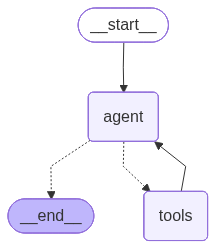

In [62]:
from IPython.display import Image, display

display(Image(agent.graph.get_graph().draw_mermaid_png()))

---
## Weekend 2 학습 요약

### 달성한 것들
1. **LegalAgentState** — TypedDict + `Annotated[list, add_messages]`로 상태 정의
2. **노드 분리** — classify / search / analyze / term / general
3. **StateGraph** — 기본 흐름 + 조건부 라우팅 (질문 유형별 분기)
4. **ReAct 패턴** — 도구 호출 ⇄ 에이전트 반복 루프
5. **MemorySaver** — thread_id 별 대화 이력 영속화
6. **Human-in-the-Loop** — 도구 실행 전 interrupt + 사용자 승인
7. **`LegalGraphAgent`** — 통합 그래프 (Weekend 3의 출발점)

### Weekend 3 예고 (Adaptive / Self / Corrective RAG)
- 질문 난이도별 Adaptive Routing (easy / medium / hard)
- Self RAG: 관련성 평가 + 답변 품질 평가 + 재생성 루프
- Corrective RAG: 문서 등급화 + 폴백 검색
- 3종 RAG 통합 → `LegalRAGAgent` 완성